<a href="https://colab.research.google.com/github/SanjaraT/Attention-Based-Multi-Scale-Ensemble-Network-for-Diabetic-Retinopathy-Detection/blob/main/notebooks/DR_Attention_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanjara9933","key":"8985c3f5225989948db98acc2fb01820"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-gaussian-filtered

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
License(s): CC0-1.0
100% 427M/427M [00:26<00:00, 17.2MB/s]



In [3]:
!unzip -q diabetic-retinopathy-224x224-gaussian-filtered.zip

# Libraries

In [21]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

warnings.filterwarnings("ignore")

# Dataset

In [22]:
import os

dataset_path = "/content/gaussian_filtered_images/gaussian_filtered_images"

print(os.listdir(dataset_path))

['Mild', 'export.pkl', 'Severe', 'No_DR', 'Moderate', 'Proliferate_DR']


# Dataset Description

In [23]:
total_images = 0

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_images += count

        print(f"{cls}: {count}")

print("\nTotal Images:", total_images)

Mild: 370
Severe: 193
No_DR: 1805
Moderate: 999
Proliferate_DR: 295

Total Images: 3662


# Data Frame

In [24]:
import pandas as pd
dataset_path = "/content/gaussian_filtered_images/gaussian_filtered_images"

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        image_paths.append(
            os.path.join(class_path, img_name)
        )

        if class_name == "No_DR":
            labels.append("NO_DR")
        else:
            labels.append("DR")

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print(df["label"].value_counts())
print(df.shape)

label
DR       1857
NO_DR    1805
Name: count, dtype: int64
(3662, 2)


In [7]:
print(df.isnull().sum())

filepath    0
label       0
dtype: int64


# Class Distribution Plot

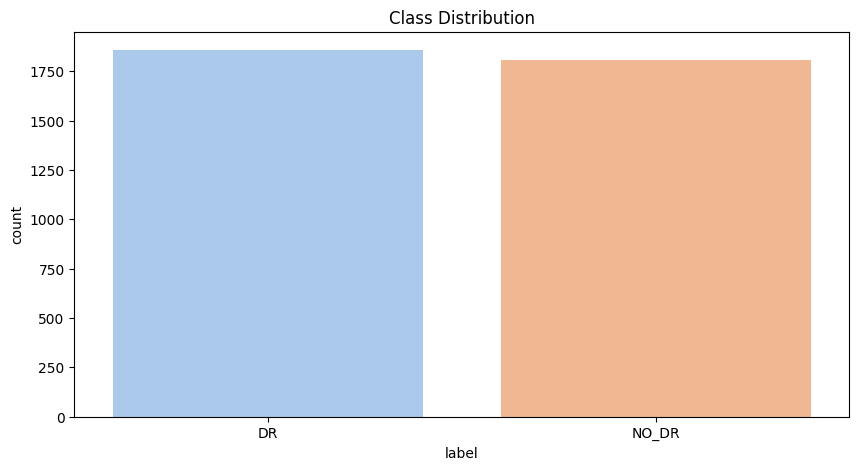

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='label',
    palette='pastel',
    hue='label',
    legend=False
)

plt.title("Class Distribution")
plt.show()

# Sample Images

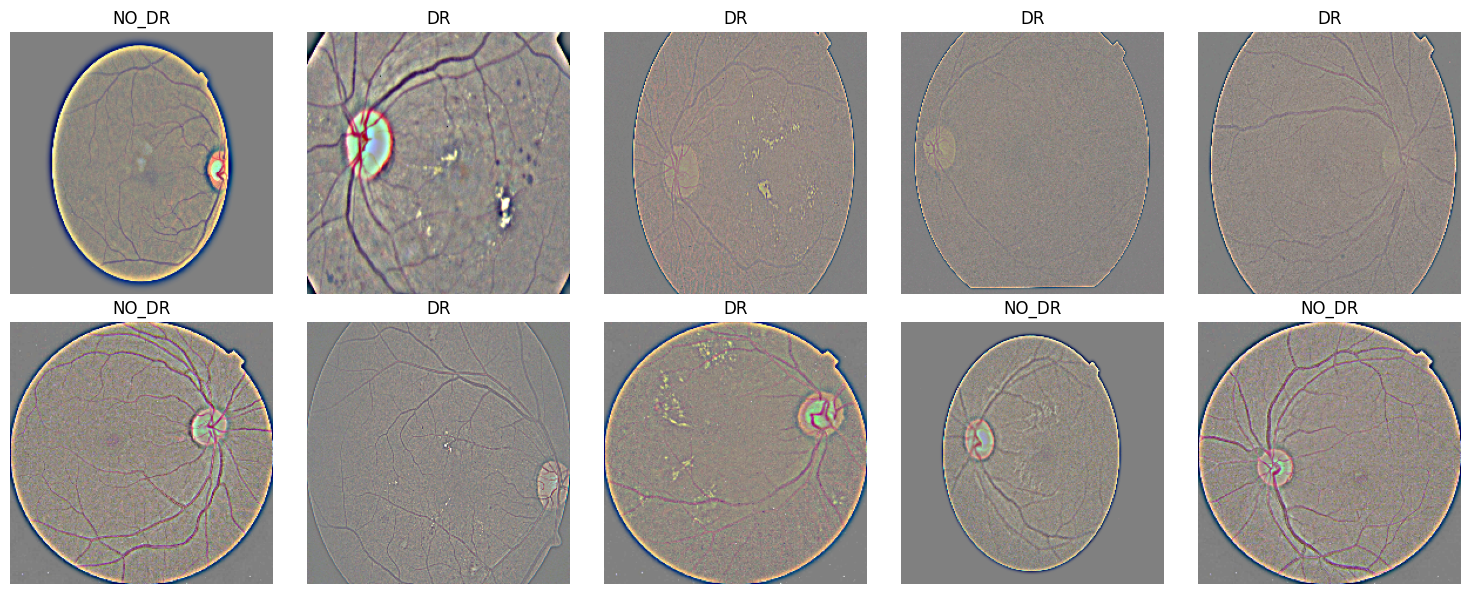

In [9]:
import cv2
import random

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for ax in axes.flat:

    idx = random.randint(0, len(df)-1)

    img = cv2.imread(
        df.iloc[idx]["filepath"]
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)

    ax.set_title(
        df.iloc[idx]["label"]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Train/Test Split

In [25]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2563
Validation: 549
Test: 550


# Class Weights

In [26]:
classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    i: weight
    for i, weight in enumerate(weights)
}

print(class_weights)

{0: np.float64(0.9857692307692307), 1: np.float64(1.0146476642913698)}


# Parameters

In [27]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Data Augmentation

In [28]:
def preprocess(img):
    img = preprocess_input(img)
    return img

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess
)

# Generators

In [29]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2563 validated image filenames belonging to 2 classes.
Found 549 validated image filenames belonging to 2 classes.
Found 550 validated image filenames belonging to 2 classes.


# Attention Block

In [30]:
def attention_block(inputs):

    attention = Dense(
        inputs.shape[-1],
        activation="sigmoid"
    )(inputs)

    output = Multiply()(
        [inputs, attention]
    )

    return output

# EfiicientNet Model

In [31]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))

x = base_model(
    inputs,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = attention_block(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1280)      │  1,639,680 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1280)      │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    327,936 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,055,332 (23.10 MB)

 Trainable params: 2,003,201 (7.64 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

# Model Compilation

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Callbacks

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_binary_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True
)

# Training

In [34]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 108s 941ms/step - accuracy: 0.8631 - auc: 0.9289 - loss: 0.3598 - val_accuracy: 0.9217 - val_auc: 0.9724 - val_loss: 0.4076 - learning_rate: 1.0000e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 454ms/step - accuracy: 0.9345 - auc: 0.9694 - loss: 0.2134 - val_accuracy: 0.9344 - val_auc: 0.9839 - val_loss: 0.2730 - learning_rate: 1.0000e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 457ms/step - accuracy: 0.9391 - auc: 0.9745 - loss: 0.1897 - val_accuracy: 0.9490 - val_auc: 0.9883 - val_loss: 0.1905 - learning_rate: 1.0000e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 461ms/step - accuracy: 0.9536 - auc: 0.9793 - loss: 0.1636 - val_accuracy: 0.9526 - val_auc: 0.9919 - val_loss: 0.1458 - learning_rate: 1.0000e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 38s 469ms/step - accuracy: 0.9508 - auc: 0.9834 - loss: 0.1521 - val_accuracy: 0.9545 - val_auc: 0.9932 - val_loss: 0.1329 - learning_rate: 1.0000e-04
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 451ms/step -

# Fine-tuning

In [35]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Final training

In [36]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 108s 859ms/step - accuracy: 0.9025 - auc: 0.9675 - loss: 0.2444 - val_accuracy: 0.9545 - val_auc: 0.9927 - val_loss: 0.1116 - learning_rate: 1.0000e-05
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 453ms/step - accuracy: 0.9259 - auc: 0.9745 - loss: 0.2057 - val_accuracy: 0.9526 - val_auc: 0.9918 - val_loss: 0.1172 - learning_rate: 1.0000e-05
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 455ms/step - accuracy: 0.9329 - auc: 0.9761 - loss: 0.1927 - val_accuracy: 0.9435 - val_auc: 0.9913 - val_loss: 0.1208 - learning_rate: 1.0000e-05
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 460ms/step - accuracy: 0.9337 - auc: 0.9734 - loss: 0.2008 - val_accuracy: 0.9454 - val_auc: 0.9909 - val_loss: 0.1232 - learning_rate: 2.0000e-06
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 457ms/step - accuracy: 0.9419 - auc: 0.9779 - loss: 0.1840 - val_accuracy: 0.9454 - val_auc: 0.9906 - val_loss: 0.1243 - learning_rate: 2.0000e-06
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 451ms/step -

# Evaluation

In [37]:
results = model.evaluate(
    test_generator
)

print(results)

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 718ms/step - accuracy: 0.9564 - auc: 0.9937 - loss: 0.1054
[0.10538657754659653, 0.9563636183738708, 0.993737518787384]


# Confusion Matrix

18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 508ms/step


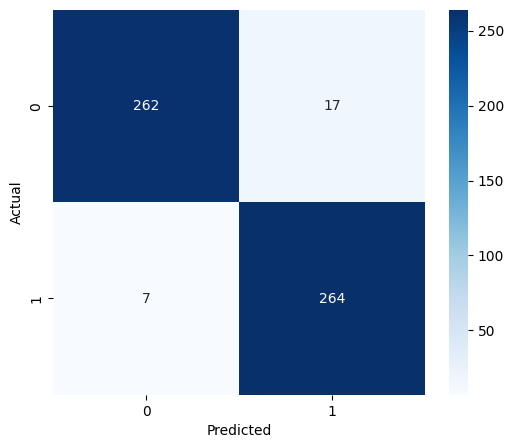

In [38]:
pred_probs = model.predict(test_generator)

preds = (pred_probs > 0.5).astype(int)

cm = confusion_matrix(
    test_generator.classes,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


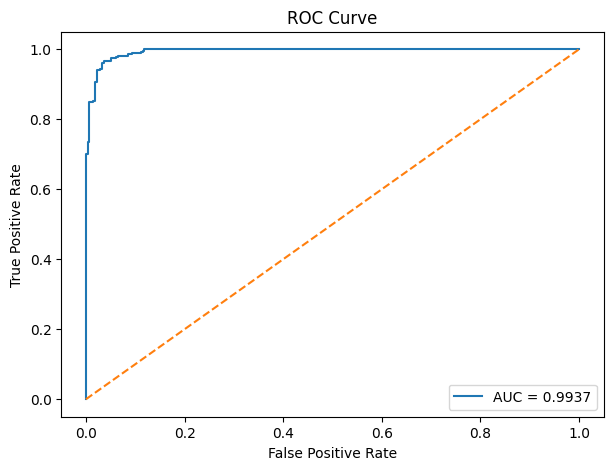

In [39]:
from sklearn.metrics import roc_curve, auc

pred_probs = model.predict(test_generator)

fpr, tpr, _ = roc_curve(
    test_generator.classes,
    pred_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Classification Report

In [41]:
from sklearn.metrics import classification_report
import io
import sys

pred_probs = model.predict(test_generator)

preds = (pred_probs > 0.5).astype(int)

# Redirect stdout to capture the print output
old_stdout = sys.stdout
sys.stdout = new_stdout = io.StringIO()

print(
    classification_report(
        test_generator.classes,
        preds
    )
)

# Restore stdout
sys.stdout = old_stdout

# Get the captured report string
report_string = new_stdout.getvalue()

# Print to display in the notebook output
print(report_string)

# Save the report to a file
with open('classification_report.txt', 'w') as f:
    f.write(report_string)

print("Classification report saved to 'classification_report.txt'")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       279
           1       0.94      0.97      0.96       271

    accuracy                           0.96       550
   macro avg       0.96      0.96      0.96       550
weighted avg       0.96      0.96      0.96       550


Classification report saved to 'classification_report.txt'


# Training Curves

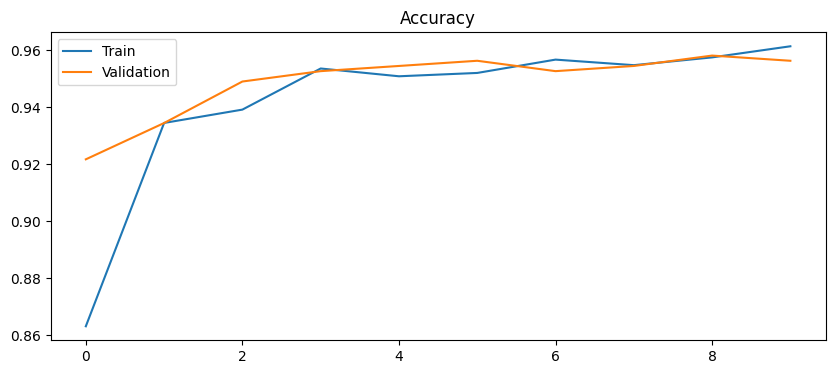

In [42]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

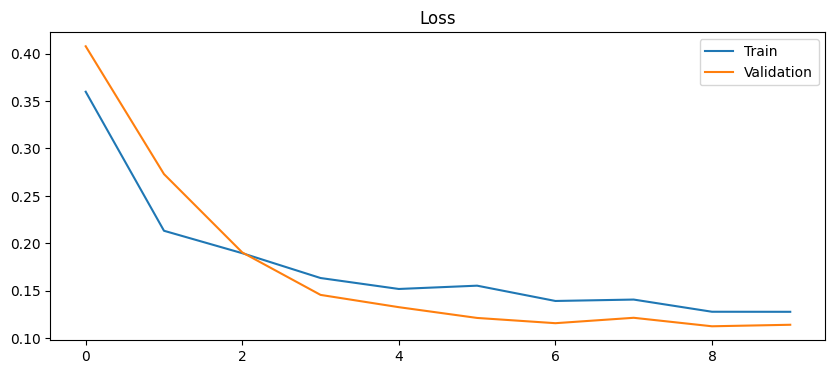

In [43]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()

# GRAD-CAM

In [46]:
import random

sample_path = random.choice(
    test_df["filepath"].tolist()
)

print(sample_path)

/content/gaussian_filtered_images/gaussian_filtered_images/Severe/1623e8e3adc4.png


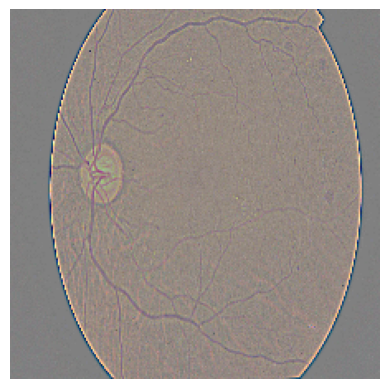

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(sample_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = cv2.resize(
    img,
    (224,224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess Image

In [58]:
from tensorflow.keras.applications.efficientnet import preprocess_input

img_array = np.expand_dims(
    img.astype(np.float32),
    axis=0
)

img_array = preprocess_input(
    img_array
)

# GRAD-CAM Function

In [65]:
img_array = preprocess_input(
    np.expand_dims(img.astype(np.float32), axis=0)
)

feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("top_conv").output
)

with tf.GradientTape() as tape:

    conv_outputs = feature_extractor(img_array)

    tape.watch(conv_outputs)

    score = tf.reduce_mean(conv_outputs)

grads = tape.gradient(
    score,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(
    heatmap,
    0
)

heatmap /= (
    tf.reduce_max(heatmap) + 1e-8
)

heatmap = heatmap.numpy()

# Visulaizing Heatmap

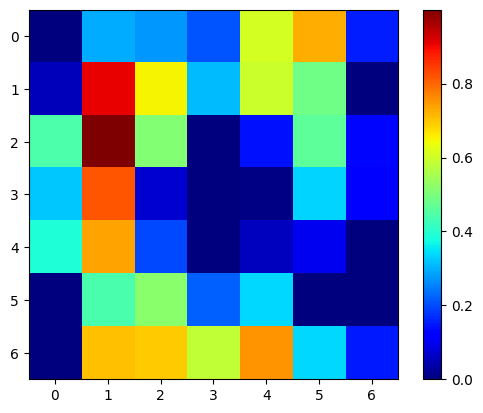

In [67]:
plt.imshow(
    heatmap,
    cmap='jet'
)

plt.colorbar()

plt.show()

# Visualizing Overlay

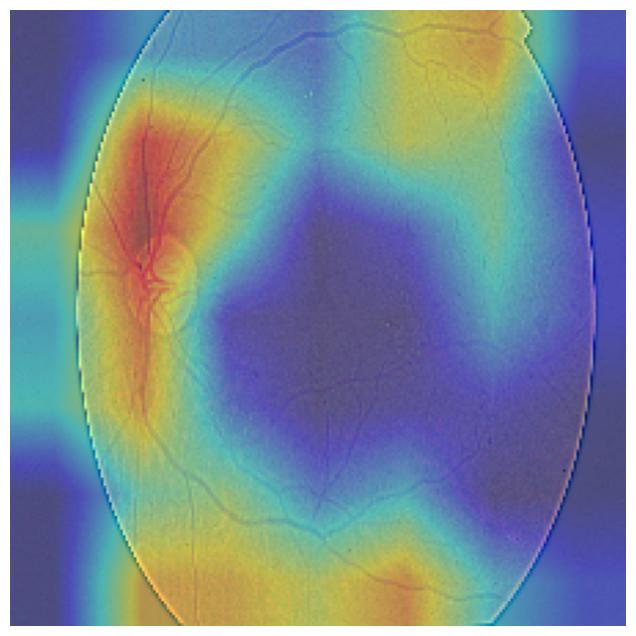

In [68]:
heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

heatmap_resized = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap_color,
    0.4,
    0
)

overlay = cv2.cvtColor(
    overlay,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

In [69]:
plt.imsave(
    "original_retina.png",
    img
)

plt.imsave(
    "gradcam_heatmap.png",
    heatmap,
    cmap="jet"
)

plt.imsave(
    "gradcam_overlay.png",
    overlay
)

### Save the Fine-tuned Model

It's a good practice to save your trained model so you can load it later without retraining. The `model.save()` method saves the model's architecture, weights, and training configuration (optimizer, loss, metrics).

In [71]:
model.save('fine_tuned_model.keras')
print("Model saved as 'fine_tuned_model.keras'")

Model saved as 'fine_tuned_model.keras'
